In [14]:
import pandas as pd
import numpy as np
import os
import glob

# 1. DANH SÁCH ĐẶC TRƯNG
SELECTED_FEATURES = [
    'IAT', 'syn_flag_number', 'psh_flag_number', 'fin_flag_number', 
    'rst_flag_number', 'ack_flag_number', 'Tot sum', 'Protocol Type', 
    'flow_duration', 'Rate', 'Std', 'Variance', 'UDP', 'TCP', 'HTTP', 
    'HTTPS', 'DNS', 'Duration', 'Number', 'ICMP', 'Magnitue', 
    'Header_Length', 'AVG', 'Min', 'Max'
]

# 2. CẤU HÌNH ĐƯỜNG DẪN
INPUT_DIR = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/' 
LABEL_MAP_PATH = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'
OUTPUT_DATA = '/kaggle/working/layer2_grouped_ddos_data.csv.gz'

SAMPLES_PER_FILE = 100000 

# 3. MAPPING LOGIC TẦNG 2: GỘP NHÓM THEO ĐẶC TRƯNG TƯƠNG ĐỒNG
ddos_grouping_logic = {
    # Nhóm 1: Giao thức TCP (Connection/Stateful)
    'DDoS-TCP_Flood': 'DDoS_TCP',
    'DDoS-SYN_Flood': 'DDoS_TCP',
    'DDoS-PSHACK_Flood': 'DDoS_TCP',
    'DDoS-RSTFINFlood': 'DDoS_TCP',
    'DDoS-SynonymousIP_Flood': 'DDoS_TCP',
    'DDoS-ACK_Fragmentation': 'DDoS_TCP',

    # Nhóm 2: Giao thức UDP (Bandwidth/Connectionless)
    'DDoS-UDP_Flood': 'DDoS_UDP',
    'DDoS-UDP_Fragmentation': 'DDoS_UDP',

    # Nhóm 3: Giao thức ICMP (Network Control)
    'DDoS-ICMP_Flood': 'DDoS_ICMP',
    'DDoS-ICMP_Fragmentation': 'DDoS_ICMP',

    # Nhóm 4: Tầng Ứng dụng (Layer 7 / Web Resource)
    'DDoS-HTTP_Flood': 'DDoS_AppLayer',
    'DDoS-SlowLoris': 'DDoS_AppLayer'
}

def basic_clean(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    return df

def process_layer2_grouping():
    label_lookup = pd.read_csv(LABEL_MAP_PATH)
    first_write = True
    
    csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
    print(f"Bắt đầu quy trình lấy mẫu Tầng 2 (Gộp nhóm DDoS) trên {len(csv_files)} file...")

    group_counts = {'DDoS_TCP': 0, 'DDoS_UDP': 0, 'DDoS_ICMP': 0, 'DDoS_AppLayer': 0}

    for file_path in csv_files:
        temp_df = pd.read_csv(file_path, nrows=1)
        if 'label' not in temp_df.columns: continue
        label_id = temp_df['label'].iloc[0]
        
        match = label_lookup[label_lookup['Encoded_ID'] == label_id]
        if match.empty: continue
        original_name = match['Original_Label'].values[0]
        
        # Chỉ xử lý nếu tên gốc nằm trong từ điển gộp nhóm DDoS
        if original_name not in ddos_grouping_logic:
            continue
            
        group_name = ddos_grouping_logic[original_name]
            
        # Đọc dữ liệu
        available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols = [c for c in SELECTED_FEATURES if c in available_cols]
        df_full = pd.read_csv(file_path, usecols=use_cols)
        
        df_cleaned = basic_clean(df_full)
        if len(df_cleaned) == 0: continue
        
        # Lấy random mẫu (Tối đa 100k dòng cho mỗi file con, để khi gộp lại dữ liệu được đa dạng)
        num_sample = min(len(df_cleaned), SAMPLES_PER_FILE)
        df_sampled = df_cleaned.sample(n=num_sample, random_state=42)
        
        # Gán nhãn bằng tên Nhóm (Thay vì ID số)
        df_sampled['layer2_label'] = group_name
        group_counts[group_name] += num_sample
        
        # Ghi file nối tiếp
        if first_write:
            df_sampled.to_csv(OUTPUT_DATA, index=False, compression='gzip')
            first_write = False
        else:
            df_sampled.to_csv(OUTPUT_DATA, mode='a', index=False, header=False, compression='gzip')
            
        print(f"Đã gộp: {original_name} vào nhóm -> {group_name} ({num_sample} dòng)")
        del df_full, df_cleaned, df_sampled

    print("\n--- TỔNG KẾT DỮ LIỆU TẦNG 2 ĐÃ XUẤT ---")
    for group, count in group_counts.items():
        print(f"Nhóm {group}: {count} dòng")
    print("--- HOÀN TẤT ---")

if __name__ == "__main__":
    process_layer2_grouping()

Bắt đầu quy trình lấy mẫu Tầng 2 (Gộp nhóm DDoS) trên 34 file...
Đã gộp: DDoS-SynonymousIP_Flood vào nhóm -> DDoS_TCP (100000 dòng)
Đã gộp: DDoS-RSTFINFlood vào nhóm -> DDoS_TCP (100000 dòng)
Đã gộp: DDoS-UDP_Fragmentation vào nhóm -> DDoS_UDP (100000 dòng)
Đã gộp: DDoS-UDP_Flood vào nhóm -> DDoS_UDP (100000 dòng)
Đã gộp: DDoS-TCP_Flood vào nhóm -> DDoS_TCP (100000 dòng)
Đã gộp: DDoS-ICMP_Flood vào nhóm -> DDoS_ICMP (100000 dòng)
Đã gộp: DDoS-HTTP_Flood vào nhóm -> DDoS_AppLayer (28790 dòng)
Đã gộp: DDoS-PSHACK_Flood vào nhóm -> DDoS_TCP (100000 dòng)
Đã gộp: DDoS-ICMP_Fragmentation vào nhóm -> DDoS_ICMP (100000 dòng)
Đã gộp: DDoS-SlowLoris vào nhóm -> DDoS_AppLayer (23426 dòng)
Đã gộp: DDoS-SYN_Flood vào nhóm -> DDoS_TCP (100000 dòng)
Đã gộp: DDoS-ACK_Fragmentation vào nhóm -> DDoS_TCP (100000 dòng)

--- TỔNG KẾT DỮ LIỆU TẦNG 2 ĐÃ XUẤT ---
Nhóm DDoS_TCP: 600000 dòng
Nhóm DDoS_UDP: 200000 dòng
Nhóm DDoS_ICMP: 200000 dòng
Nhóm DDoS_AppLayer: 52216 dòng
--- HOÀN TẤT ---


=> Đang tải dữ liệu Tầng 2...
Các nhóm đã nhận diện: ['DDoS_AppLayer', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP']

=> Bắt đầu huấn luyện và đánh giá 5-Fold CV...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[137]	valid_0's multi_logloss: 0.000476506
   + Xong Fold 1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[149]	valid_0's multi_logloss: 0.000317108
   + Xong Fold 2
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[147]	valid_0's multi_logloss: 0.000546324
   + Xong Fold 3
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[145]	valid_0's multi_logloss: 0.000321313
   + Xong Fold 4
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[143]	valid_0's multi_logloss: 0.000465781
   + Xong Fold 5

⭐ KẾT QUẢ ĐÁNH GIÁ TRUNG BÌNH (5-FOLD) - TẦNG 2
---------------

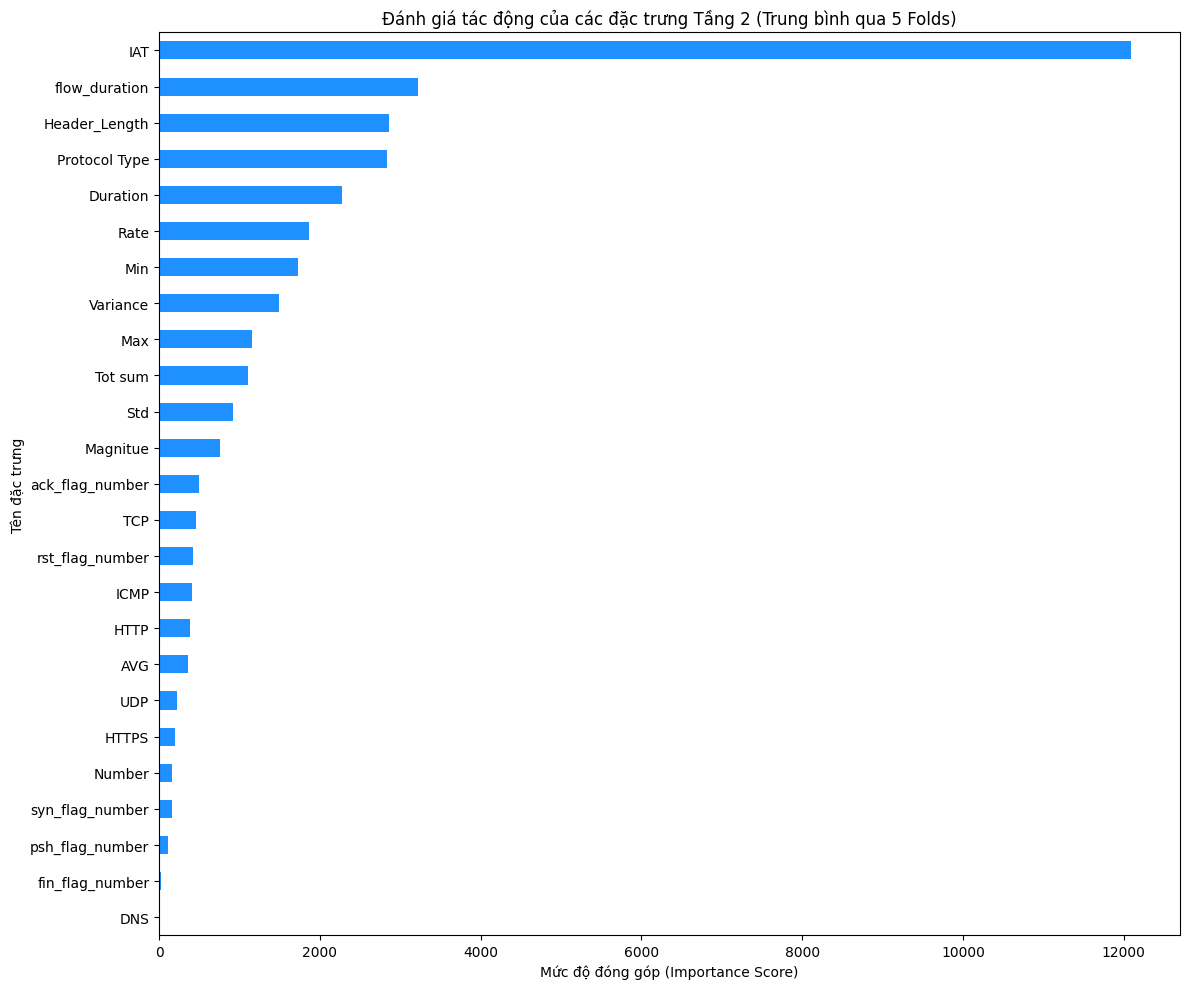

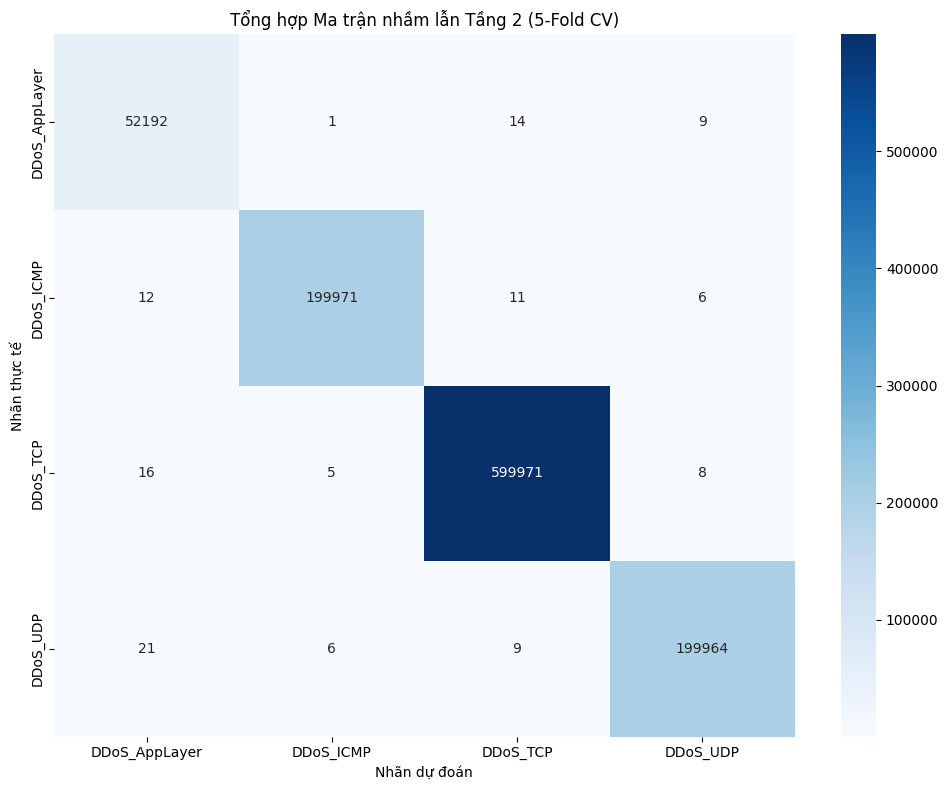

In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# --- 1. CẤU HÌNH ---
INPUT_FILE = '/kaggle/working/layer2_grouped_ddos_data.csv.gz'
K_FOLDS = 5

print("=> Đang tải dữ liệu Tầng 2...")
df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.strip()

# Tách Features và Target
X = df.drop(columns=['layer2_label'])
y_raw = df['layer2_label']

# Chuyển đổi nhãn dạng chữ sang dạng số cho LightGBM
le = LabelEncoder()
y = pd.Series(le.fit_transform(y_raw))
target_names = le.classes_
print(f"Các nhóm đã nhận diện: {list(target_names)}")

# --- 2. THIẾT LẬP K-FOLD ---
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_metrics = []
all_latency = []
oof_preds = np.zeros(len(df))
feature_importance_df = pd.DataFrame() 

print(f"\n=> Bắt đầu huấn luyện và đánh giá {K_FOLDS}-Fold CV...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Cấu hình tham số LightGBM 
    params = {
        'objective': 'multiclass', 
        'num_class': len(np.unique(y)),
        'metric': 'multi_logloss', 
        'is_unbalance': True,
        'learning_rate': 0.05, 
        'num_leaves': 63, 
        'max_bin': 255,
        'min_data_in_leaf':50,
        'device': 'cpu', 
        'verbose': -1, 
        'seed': 42
    }
    
    train_set = lgb.Dataset(X_train, label=y_train)
    val_set = lgb.Dataset(X_val, label=y_val, reference=train_set)
    
    model = lgb.train(
        params, 
        train_set, 
        valid_sets=[val_set], 
        num_boost_round=2000, 
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )
    
    # ĐO THỜI GIAN DỰ ĐOÁN
    start_pred = time.time()
    y_prob = model.predict(X_val)
    end_pred = time.time()
    
    y_pred = np.argmax(y_prob, axis=1)
    oof_preds[val_idx] = y_pred
    
    # Tính Latency (ms/sample)
    latency_per_sample = (end_pred - start_pred) / len(X_val)
    all_latency.append(latency_per_sample)
    
    # Lưu Feature Importance
    fold_imp = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importance()})
    feature_importance_df = pd.concat([feature_importance_df, fold_imp], axis=0)
    
    # Lưu chỉ số
    fold_metrics.append({
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='macro'),
        'recall': recall_score(y_val, y_pred, average='macro'),
        'f1': f1_score(y_val, y_pred, average='macro')
    })
    print(f"   + Xong Fold {fold+1}")

# --- 3. TÍNH TOÁN KẾT QUẢ ---
metrics_df = pd.DataFrame(fold_metrics)
avg_metrics = metrics_df.mean()
std_metrics = metrics_df.std()
avg_latency_ms = np.mean(all_latency) * 1000

# --- 4. IN KẾT QUẢ RA MÀN HÌNH ---
print("\n" + "="*50)
print(f"⭐ KẾT QUẢ ĐÁNH GIÁ TRUNG BÌNH ({K_FOLDS}-FOLD) - TẦNG 2")
print("-" * 50)
print(f"1. Accuracy:  {avg_metrics['accuracy']:.4f} (±{std_metrics['accuracy']:.4f})")
print(f"2. Precision: {avg_metrics['precision']:.4f} (±{std_metrics['precision']:.4f})")
print(f"3. Recall:    {avg_metrics['recall']:.4f} (±{std_metrics['recall']:.4f})")
print(f"4. F1-Score:  {avg_metrics['f1']:.4f} (±{std_metrics['f1']:.4f})")
print("-" * 50)
print(f"⏱ Tốc độ xử lý trung bình: {avg_latency_ms:.6f} ms/dòng")
print("="*50)

# Báo cáo chi tiết từng lớp
print("\nBáo cáo phân loại chi tiết (Tổng hợp OOF):")
print(classification_report(y, oof_preds, target_names=target_names))

# --- 5. VẼ BIỂU ĐỒ ĐÁNH GIÁ TÁC ĐỘNG (FEATURE IMPORTANCE) ---
plt.figure(figsize=(12, 10))
mean_imp = feature_importance_df.groupby('Feature')['Importance'].mean().sort_values(ascending=True)
mean_imp.plot(kind='barh', color='dodgerblue')
plt.title(f'Đánh giá tác động của các đặc trưng Tầng 2 (Trung bình qua {K_FOLDS} Folds)')
plt.xlabel('Mức độ đóng góp (Importance Score)')
plt.ylabel('Tên đặc trưng')
plt.tight_layout()
plt.savefig('/kaggle/working/layer2_feature_importance.png')
plt.show()

# Luu xếp hạng đặc trưng
mean_imp.sort_values(ascending=False).to_csv('/kaggle/working/layer2_feature_impact_ranking.csv')

# --- 6. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
cm = confusion_matrix(y, oof_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Tổng hợp Ma trận nhầm lẫn Tầng 2 ({K_FOLDS}-Fold CV)')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.savefig('/kaggle/working/layer2_confusion_matrix.png')
plt.show()

In [16]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import time
from sklearn.preprocessing import LabelEncoder

# --- 1. CẤU HÌNH ĐẦU VÀO & ĐẦU RA ---
INPUT_FILE = '/kaggle/working/layer2_grouped_ddos_data.csv.gz'
MODEL_SAVE_PATH = '/kaggle/working/lightgbm_layer2_ddos_model.txt'
LABEL_ENCODER_PATH = '/kaggle/working/layer2_label_encoder.pkl' # Lưu lại bộ dịch nhãn
META_DATA_PATH = '/kaggle/working/layer2_model_meta.pkl'

print("=> Đang tải toàn bộ dữ liệu Tầng 2 để huấn luyện...")
df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.strip()

# Tách X (Features) và y (Target)
X = df.drop(columns=['layer2_label'])
y_raw = df['layer2_label']

# Mã hóa nhãn dạng chữ sang số
print("=> Đang mã hóa nhãn và lưu LabelEncoder...")
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Lưu LabelEncoder để dùng cho file test/dự đoán sau này
with open(LABEL_ENCODER_PATH, 'wb') as f:
    pickle.dump(le, f)
print(f"   + Đã nhận diện các lớp: {list(le.classes_)}")

# --- 2. THIẾT LẬP THAM SỐ (Dựa trên cấu hình tối ưu của cậu) ---
params = {
    'objective': 'multiclass',
    'num_class': len(np.unique(y)),
    'metric': 'multi_logloss',
    'is_unbalance': True,       # Xử lý mất cân bằng dữ liệu
    'learning_rate': 0.015,      
    'num_leaves': 255,          
    'max_bin': 511,             # Độ phân giải cao cho các đặc trưng mạng
    'device': 'cpu',
    'verbose': -1,
    'seed': 42
}

# --- 3. HUẤN LUYỆN TRÊN TOÀN BỘ DỮ LIỆU ---
print(f"\n=> Đang huấn luyện mô hình trên toàn bộ {len(df):,} dòng dữ liệu...")
start_time = time.time()

# Tạo Dataset cho LightGBM
train_set = lgb.Dataset(X, label=y)

# Huấn luyện (Không dùng early stopping vì train trên toàn bộ tập dữ liệu)
final_model = lgb.train(
    params, 
    train_set, 
    num_boost_round=2000
)

end_time = time.time()
training_duration = end_time - start_time

# --- 4. LƯU MÔ HÌNH VÀ SIÊU DỮ LIỆU ---
print(f"\n=> Huấn luyện hoàn tất trong {training_duration:.2f} giây.")

# Lưu mô hình (Dạng text để LightGBM load lại cực nhanh trong C++ hoặc Python)
final_model.save_model(MODEL_SAVE_PATH)
print(f"   [+] Đã lưu mô hình tại: {MODEL_SAVE_PATH}")

# Lưu danh sách đặc trưng để đảm bảo khi dự đoán hệ thống mạng thực tế không bị lệch cột
model_info = {
    'features': list(X.columns),
    'num_class': params['num_class']
}
with open(META_DATA_PATH, 'wb') as f:
    pickle.dump(model_info, f)

print("=> HỆ THỐNG TẦNG 2 ĐÃ SẴN SÀNG ĐỂ DỰ ĐOÁN THỰC TẾ!")

=> Đang tải toàn bộ dữ liệu Tầng 2 để huấn luyện...
=> Đang mã hóa nhãn và lưu LabelEncoder...
   + Đã nhận diện các lớp: ['DDoS_AppLayer', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP']

=> Đang huấn luyện mô hình trên toàn bộ 1,052,216 dòng dữ liệu...

=> Huấn luyện hoàn tất trong 490.29 giây.
   [+] Đã lưu mô hình tại: /kaggle/working/lightgbm_layer2_ddos_model.txt
=> HỆ THỐNG TẦNG 2 ĐÃ SẴN SÀNG ĐỂ DỰ ĐOÁN THỰC TẾ!


In [17]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import os
import glob
import random

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN & THÔNG SỐ
# ==========================================
MODEL_PATH = '/kaggle/working/lightgbm_layer2_ddos_model.txt'
LABEL_ENCODER_PATH = '/kaggle/working/layer2_label_encoder.pkl'
META_DATA_PATH = '/kaggle/working/layer2_model_meta.pkl'

INPUT_DIR = '/kaggle/input/datasets/nguyenleanhtuan07/b-data-scale-encoding-v-chia-theo-tng-label/' 
LABEL_MAP_PATH = '/kaggle/input/datasets/nguyenleanhtuan07/nhn-34/label_map_key.csv'

ddos_grouping_logic = {
    'DDoS-TCP_Flood': 'DDoS_TCP', 'DDoS-SYN_Flood': 'DDoS_TCP', 'DDoS-PSHACK_Flood': 'DDoS_TCP',
    'DDoS-RSTFINFlood': 'DDoS_TCP', 'DDoS-SynonymousIP_Flood': 'DDoS_TCP', 'DDoS-ACK_Fragmentation': 'DDoS_TCP',
    'DDoS-UDP_Flood': 'DDoS_UDP', 'DDoS-UDP_Fragmentation': 'DDoS_UDP',
    'DDoS-ICMP_Flood': 'DDoS_ICMP', 'DDoS-ICMP_Fragmentation': 'DDoS_ICMP',
    'DDoS-HTTP_Flood': 'DDoS_AppLayer', 'DDoS-SlowLoris': 'DDoS_AppLayer'
}

print("=> Đang khởi động hệ thống AI Tầng 2...")
model = lgb.Booster(model_file=MODEL_PATH)
with open(LABEL_ENCODER_PATH, 'rb') as f: le = pickle.load(f)
with open(META_DATA_PATH, 'rb') as f: expected_features = pickle.load(f)['features']


# ==========================================
# 2. SINH TRỌNG SỐ (FEATURE WEIGHTS)
# ==========================================
print("\n" + "="*50)
print("⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG")
print("="*50)

weights = model.feature_importance(importance_type='gain')
weight_df = pd.DataFrame({
    'Feature': expected_features,
    'Weight (Gain)': weights
})

weight_df = weight_df.sort_values(by='Weight (Gain)', ascending=False)
weight_df['Contribution (%)'] = (weight_df['Weight (Gain)'] / weight_df['Weight (Gain)'].sum()) * 100

print(weight_df.head(10).to_string(index=False))
weight_df.to_csv('/kaggle/working/layer2_feature_weights.csv', index=False)
print("\n[+] Đã lưu toàn bộ trọng số ra file: /kaggle/working/layer2_feature_weights.csv")


# ==========================================
# 3. THUẬT TOÁN BỐC RANDOM & TEST NHANH 10 MẪU
# ==========================================
print("\n" + "="*50)
print("🚀 BƯỚC 2: BLIND TEST TRÊN DATA GỐC (50 TRIỆU DÒNG)")
print("="*50)

csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
label_lookup = pd.read_csv(LABEL_MAP_PATH)
label_dict = dict(zip(label_lookup['Encoded_ID'], label_lookup['Original_Label']))

random.shuffle(csv_files) # Đảo lộn thứ tự file
sample_data = []
target_samples = 10
samples_per_file = 2 

print(f"=> Đang săn lùng ngẫu nhiên {target_samples} mẫu DDoS...")

for file_path in csv_files:
    temp_df = pd.read_csv(file_path, nrows=1)
    if 'label' not in temp_df.columns: continue
    
    file_label_id = temp_df['label'].iloc[0]
    original_name = label_dict.get(file_label_id, "")
    
    if original_name in ddos_grouping_logic:
        available_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols = [c for c in expected_features if c in available_cols]
        df_full = pd.read_csv(file_path, usecols=use_cols)
        
        df_cleaned = df_full.replace([np.inf, -np.inf], np.nan).dropna()
        if len(df_cleaned) == 0: continue
            
        take_n = min(len(df_cleaned), samples_per_file)
        
        if sum(len(d) for d in sample_data) + take_n > target_samples:
            take_n = target_samples - sum(len(d) for d in sample_data)
            
        if take_n > 0:
            df_sampled = df_cleaned.sample(n=take_n)
            df_sampled['True_Answer'] = ddos_grouping_logic[original_name]
            sample_data.append(df_sampled)
            
        if sum(len(d) for d in sample_data) >= target_samples:
            break

# Tiến hành dự đoán và so sánh
if not sample_data:
    print("Không tìm thấy dữ liệu DDoS.")
else:
    test_df = pd.concat(sample_data, ignore_index=True)
    test_df = test_df.sample(frac=1.0).reset_index(drop=True)
    
    X_test = test_df[expected_features]
    true_answers = test_df['True_Answer'].tolist()
    
    y_prob = model.predict(X_test)
    y_pred_indices = np.argmax(y_prob, axis=1)
    confidence_scores = np.max(y_prob, axis=1) * 100
    y_pred_names = le.inverse_transform(y_pred_indices)
    
    correct_count = 0
    print("\n--- KẾT QUẢ CHẨN ĐOÁN ---")
    for i in range(len(test_df)):
        print(f"🔹 Gói tin mạng thứ {i+1}:")
        print(f"   - Nhãn thực tế: {true_answers[i]}")
        print(f"   - AI Dự đoán:   {y_pred_names[i]} (Độ tự tin: {confidence_scores[i]:.2f}%)")
        
        if true_answers[i] == y_pred_names[i]:
            print("   => ✅ CHÍNH XÁC")
            correct_count += 1
        else:
            print("   => ❌ SAI LỆCH")
        print("-" * 30)
        
    print(f"🏆 ĐỘ CHÍNH XÁC BLIND TEST: {correct_count}/{len(test_df)} ({correct_count/len(test_df)*100:.1f}%)")

=> Đang khởi động hệ thống AI Tầng 2...

⭐ BƯỚC 1: TRÍCH XUẤT TRỌNG SỐ ĐẶC TRƯNG
        Feature  Weight (Gain)  Contribution (%)
  Protocol Type   4.083544e+07         52.396604
            IAT   1.720498e+07         22.075983
            TCP   1.500896e+07         19.258237
  Header_Length   1.778244e+06          2.281693
ack_flag_number   1.592149e+06          2.042912
            Min   5.591773e+05          0.717489
           HTTP   4.335472e+05          0.556291
  flow_duration   1.623340e+05          0.208293
rst_flag_number   1.586953e+05          0.203624
       Duration   5.473829e+04          0.070236

[+] Đã lưu toàn bộ trọng số ra file: /kaggle/working/layer2_feature_weights.csv

🚀 BƯỚC 2: BLIND TEST TRÊN DATA GỐC (50 TRIỆU DÒNG)
=> Đang săn lùng ngẫu nhiên 10 mẫu DDoS...

--- KẾT QUẢ CHẨN ĐOÁN ---
🔹 Gói tin mạng thứ 1:
   - Nhãn thực tế: DDoS_UDP
   - AI Dự đoán:   DDoS_UDP (Độ tự tin: 100.00%)
   => ✅ CHÍNH XÁC
------------------------------
🔹 Gói tin mạng thứ 2:
   - Nh